<a href="https://colab.research.google.com/github/ArmandoBarrios/unidad-3-/blob/main/practica_4_unidad_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
# Importamos librerias necesarias para Árboles de decisión
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve

#Carga el Dataset
from google.colab import drive
drive.mount('/content/drive')
#ID del archivo
#https:https:https://drive.google.com/file/d/1V5ANwclpm0o4aHH_HvFeD0P0db0rqZOO/view?usp=sharing
file_id = '1V5ANwclpm0o4aHH_HvFeD0P0db0rqZOO'
url =  f"https://drive.google.com/uc?id={file_id}"

#cargar datos
prestamos_df=pd.read_csv(url)
prestamos_df.head()

Mounted at /content/drive


,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,...,application_type,acc_now_delinq,chargeoff_within_12_mths,delinq_amnt,pub_rec_bankruptcies,tax_liens,hardship_flag,disbursement_method,debt_settlement_flag,debt_settlement_flag_date
0,2400,2400,2400.0,36 months,15.96,84.33,C,C5,NaN,10+ years,...,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN
1,10000,10000,10000.0,36 months,13.49,339.31,C,C1,AIR RESOURCES BOARD,10+ years,...,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN
2,3000,3000,3000.0,36 months,18.64,109.43,E,E1,MKC Accounting,9 years,...,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN
3,5600,5600,5600.0,60 months,21.28,152.39,F,F2,NaN,4 years,...,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN
4,5375,5375,5350.0,60 months,12.69,121.45,B,B5,Starbucks,< 1 year,...,Individual,0.0,0.0,0.0,0.0,0.0,N,Cash,N,NaN


In [2]:
prestamos_df['grade_code'] = prestamos_df['grade'].astype('category').cat.codes
prestamos_df['purpose_code'] = prestamos_df['purpose'].astype('category').cat.codes
prestamos_df['addr_state_code'] = prestamos_df['addr_state'].astype('category').cat.codes
prestamos_df['home_ownership_code'] = prestamos_df['home_ownership'].astype('category').cat.codes
X = prestamos_df[['funded_amnt', "int_rate", "grade_code", 'purpose_code', 'addr_state_code', 'home_ownership_code',
                  'annual_inc', 'dti', 'revol_util', 'pub_rec_bankruptcies']]
# Variable objetivo o variable a predecir
y = prestamos_df["loan_status"]

# Check unique values of the new target variable
print("Unique values for 'loan_status':", y.unique())

# Dividimos el dataFrame
# stratify es para que mantenga la misma proporción de clases en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size= 0.4, stratify=y)

# verificamos la cantidad de registros asignados al dataframe de entrenamiento
X_train.shape, X_test.shape, y_train.shape, y_test.shape

Unique values for 'loan_status': ['Fully Paid' 'Charged Off']


((11944, 10), (7964, 10), (11944,), (7964,))

In [3]:
# Crear el modelo de árbol de clasificación
tree_model = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
# Entrenar el modelo
tree_model.fit(X_train, y_train)
# Precisión del modelo en la fase de entrenamiento
print("Precision del clasificador en fase de entrenamiento", tree_model.score(X_train, y_train) )

Precision del clasificador en fase de entrenamiento 0.8545713328868051


In [4]:
# Hacer predicciones con los datos de prueba
y_pred = tree_model.predict(X_test)
# Crear un informe de texto que muestre las principales métricas de clasificación.
print("\nReporte de métricas del clasificador de Arboles de Decisión: \n",
classification_report(y_test, y_pred, target_names=["No Pagado", "Pagado"]))
print(f'\nMatriz Confusion de Arboles de Decisión:\n', confusion_matrix(y_test, y_pred ))



Reporte de métricas del clasificador de Arboles de Decisión: 
               precision    recall  f1-score   support

   No Pagado       0.31      0.01      0.02      1177
      Pagado       0.85      0.99      0.92      6787

    accuracy                           0.85      7964
   macro avg       0.58      0.50      0.47      7964
weighted avg       0.77      0.85      0.79      7964


Matriz Confusion de Arboles de Decisión:
 [[  15 1162]
 [  34 6753]]


In [5]:

# Crear modelo con balanceo de clases
tree_model2 = DecisionTreeClassifier(criterion='gini', max_depth=5, class_weight='balanced', random_state=42, )
# Entrenar el modelo
tree_model2.fit(X_train, y_train)
# Realizar fase de pruena
y_pred2 = tree_model2.predict(X_test)
# Evaluar el modelo
print("\nReporte de métricas del clasificador de Arboles de Decisión: \n",
classification_report(y_test, y_pred2, target_names=["No Pagado", "Pagado"]))
print("\n Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred2))



Reporte de métricas del clasificador de Arboles de Decisión: 
               precision    recall  f1-score   support

   No Pagado       0.21      0.62      0.32      1177
      Pagado       0.90      0.61      0.73      6787

    accuracy                           0.61      7964
   macro avg       0.56      0.61      0.52      7964
weighted avg       0.80      0.61      0.67      7964


 Matriz de Confusión:
[[ 727  450]
 [2667 4120]]


In [6]:
# Crear modelo con balanceo de clases y max_depth (profundidad del árbol)
tree_model3 = DecisionTreeClassifier(criterion='gini', max_depth=7, class_weight='balanced', random_state=42)
# Entrenar el modelo
tree_model3.fit(X_train, y_train)
# Realizar fase de prueba
y_pred3 = tree_model3.predict(X_test)
# Evaluar el modelo de prueba
print("\nReporte de métricas del clasificador de Arboles de Decisión: \n",
classification_report(y_test, y_pred3, target_names=["No Pagado", "Pagado"]))
print("\n Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred3))


Reporte de métricas del clasificador de Arboles de Decisión: 
               precision    recall  f1-score   support

   No Pagado       0.21      0.67      0.31      1177
      Pagado       0.91      0.55      0.69      6787

    accuracy                           0.57      7964
   macro avg       0.56      0.61      0.50      7964
weighted avg       0.80      0.57      0.63      7964


 Matriz de Confusión:
[[ 784  393]
 [3034 3753]]


In [7]:

from sklearn.tree import export_text, plot_tree
import matplotlib.pyplot as plt
model_columns = ['funded_amnt', "int_rate", "grade_code", 'purpose_code', 'addr_state_code',
'home_ownership_code', 'annual_inc', 'dti', 'revol_util',
'pub_rec_bankruptcies']
# Visualizar el árbol en texto
print(export_text(tree_model3, feature_names=model_columns))

|--- int_rate <= 11.61
|   |--- int_rate <= 8.43
|   |   |--- annual_inc <= 58272.00
|   |   |   |--- revol_util <= 20.45
|   |   |   |   |--- revol_util <= 5.35
|   |   |   |   |   |--- annual_inc <= 34500.00
|   |   |   |   |   |   |--- annual_inc <= 26296.00
|   |   |   |   |   |   |   |--- class: Fully Paid
|   |   |   |   |   |   |--- annual_inc >  26296.00
|   |   |   |   |   |   |   |--- class: Charged Off
|   |   |   |   |   |--- annual_inc >  34500.00
|   |   |   |   |   |   |--- annual_inc <= 54900.00
|   |   |   |   |   |   |   |--- class: Fully Paid
|   |   |   |   |   |   |--- annual_inc >  54900.00
|   |   |   |   |   |   |   |--- class: Charged Off
|   |   |   |   |--- revol_util >  5.35
|   |   |   |   |   |--- dti <= 11.82
|   |   |   |   |   |   |--- dti <= 11.63
|   |   |   |   |   |   |   |--- class: Fully Paid
|   |   |   |   |   |   |--- dti >  11.63
|   |   |   |   |   |   |   |--- class: Charged Off
|   |   |   |   |   |--- dti >  11.82
|   |   |   |   |   |   |

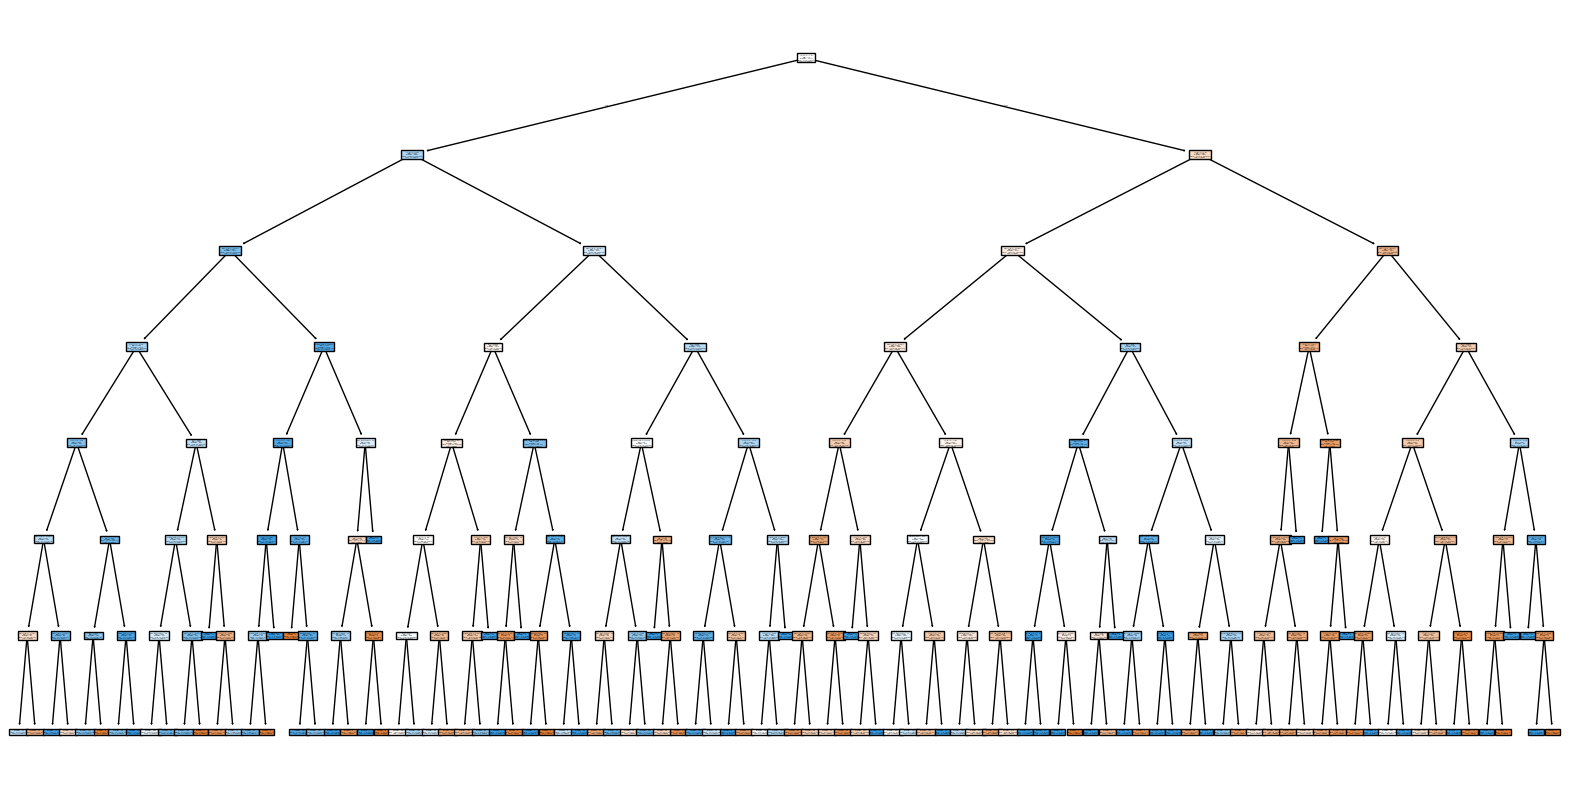

In [8]:

# Graficar el árbol
plt.figure(figsize=(20, 10))
plot_tree(tree_model3, feature_names=model_columns, class_names=['Pagado', 'No Pagado'], filled=True)
plt.show()

In [9]:

importancia_caracteristicas = pd.DataFrame({
'Caracteristica': model_columns,
'Importancia': tree_model3.feature_importances_
}).sort_values(by='Importancia', ascending=False)
print("\nImportancia de las características:")
print(importancia_caracteristicas)



Importancia de las características:
         Caracteristica   Importancia
1              int_rate  4.668801e-01
6            annual_inc  1.764909e-01
8            revol_util  1.157532e-01
7                   dti  6.718836e-02
0           funded_amnt  6.020113e-02
4       addr_state_code  4.218611e-02
3          purpose_code  4.113569e-02
9  pub_rec_bankruptcies  1.769875e-02
5   home_ownership_code  1.246583e-02
2            grade_code  6.807287e-17


In [10]:

# Graficar importancias con Plotly
import plotly.express as px
fig4 = px.bar(importancia_caracteristicas, x="Caracteristica", y="Importancia",
title="Importancia de características",
text_auto=".3f", color="Caracteristica")
fig4.update_layout(width=800, height=600)
fig4.show()


In [11]:

from sklearn.model_selection import GridSearchCV
param_grid = {
'criterion': ['gini', 'entropy'],
'max_depth': [5, 7, 10, None],
'min_samples_split': [2, 5, 10, 20],
'min_samples_leaf': [1, 2, 5, 10],
'class_weight': [None, 'balanced'],
'ccp_alpha': [0.0, 0.001, 0.01]
}
grid_search = GridSearchCV(
DecisionTreeClassifier(random_state=42),
param_grid,
scoring='recall_macro', # o 'f2' si te interesa más los impagos
cv=5,
n_jobs=-1,
verbose=2
)
grid_search.fit(X_train, y_train)
print("Mejores parámetros:", grid_search.best_params_)

Fitting 5 folds for each of 768 candidates, totalling 3840 fits
Mejores parámetros: {'ccp_alpha': 0.001, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [12]:

# Evaluación del mejor modelo
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print("\nReporte de Clasificación (modelo optimizado para detectar impagos):\n")
print(classification_report(y_test, y_pred))
print("Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred))



Reporte de Clasificación (modelo optimizado para detectar impagos):

              precision    recall  f1-score   support

 Charged Off       0.22      0.63      0.32      1177
  Fully Paid       0.90      0.60      0.72      6787

    accuracy                           0.61      7964
   macro avg       0.56      0.62      0.52      7964
weighted avg       0.80      0.61      0.66      7964

Matriz de Confusión:
[[ 741  436]
 [2702 4085]]
